# Analisis Kinerja Keuangan PT Astra International Tbk
Dataset ini diambil dari platform Stockbit, berisi riwayat laporan laba rugi perusahaan dari kuartal ke kuartal. Tujuan dari analisis ini adalah untuk mengekplorasi tren **Total Pendapatan** dan **Laba Bersih** untuk melihat seberapa stabil performa fundamental perusahaan dari waktu ke waktu.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya grafik agar terlihat lebih bersih dan modern
sns.set_theme(style="whitegrid")

## 1. Memuat Dataset
Kita akan memuat dataset yang sebelumnya sudah dibersihkan dari baris-baris kosong dan nama-nama akun yang duplikat.

In [5]:
# Ganti nama file sesuai dengan nama file dataset yang sudah bersih
df = pd.read_csv('dataset_astra.csv')

# Menjadikan kolom pertama (Nama Akun) sebagai index agar lebih mudah diekstrak
df.set_index(df.columns[0], inplace=True)

# Menampilkan 29 baris dan 5 kolom pertama untuk memastikan data terbaca dengan benar
df.iloc[:29, :5]

,Q1 2026,Q4 2025,Q3 2025,Q2 2025,Q1 2025
Dalam Miliaran IDR,,,,,
Total Pendapatan,78668.0,79784.0,80751.0,79496.0,83361.0
Total Beban Pokok Penjualan,-63174.0,-60587.0,-63337.0,-61723.0,-66301.0
Laba Kotor,15494.0,19197.0,17414.0,17773.0,17060.0
Beban Penjualan,-3167.0,-3243.0,-2922.0,-2612.0,-2967.0
Beban Umum Dan Administrasi,-6017.0,-5679.0,-5269.0,-5212.0,-4875.0
Total Beban Usaha,-9184.0,-8922.0,-8191.0,-7824.0,-7842.0
Laba Usaha,6310.0,10275.0,9223.0,9949.0,9218.0
Pendapatan Keuangan,828.0,881.0,983.0,935.0,856.0
Beban Keuangan,-923.0,-916.0,-940.0,-957.0,-921.0


## 2. Transformasi Data untuk Visualisasi
Data dari Stockbit ini memiliki struktur menyamping (setiap kolom adalah kuartal, berurut dari yang paling baru ke paling lama). 
Untuk membuat grafik *time-series* yang benar, kita harus mengekstrak baris indikator utama, lalu membalik urutannya agar mengalir secara kronologis dari masa lalu ke masa depan.

In [6]:
# Mengekstrak SELURUH baris Total Pendapatan dan Laba Bersih
pendapatan = df.loc['Total Pendapatan'].dropna()
laba_bersih = df.loc['Laba Bersih Tahun Berjalan'].dropna()

# Membalik urutan data (dari terlama ke terbaru) menggunakan slicing [::-1]
pendapatan_urut = pendapatan[::-1]
laba_bersih_urut = laba_bersih[::-1]

# Memastikan data bertipe numerik
pendapatan_urut = pd.to_numeric(pendapatan_urut, errors='coerce')
laba_bersih_urut = pd.to_numeric(laba_bersih_urut, errors='coerce')

## 3. Visualisasi Tren Kinerja
Mari kita lihat perbandingan pergerakan Total Pendapatan dan Laba Bersih selama 5 tahun terakhir.

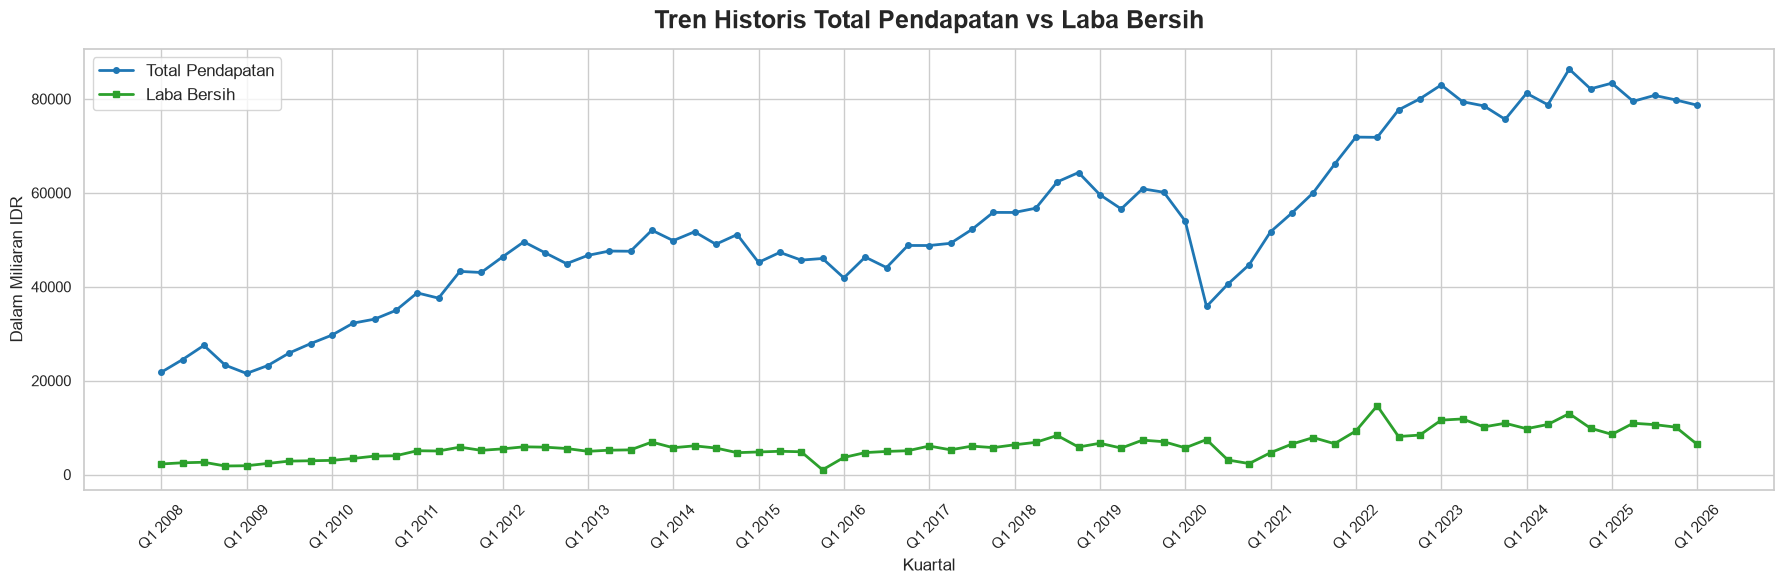

In [7]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(18, 6))

# Membuat garis untuk Pendapatan dan Laba
ax.plot(pendapatan_urut.index, pendapatan_urut.values, marker='o', markersize=4, color='#1f77b4', linewidth=2, label='Total Pendapatan')
ax.plot(laba_bersih_urut.index, laba_bersih_urut.values, marker='s', markersize=4, color='#2ca02c', linewidth=2, label='Laba Bersih')

plt.title('Tren Historis Total Pendapatan vs Laba Bersih', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Kuartal', fontsize=12)
plt.ylabel('Dalam Miliaran IDR', fontsize=12)

# Mengatur agar sumbu X tidak menampilkan semua label kuartal (maksimal 25 label saja agar rapi)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=25))
plt.xticks(rotation=45)

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 4. Analisis Net Profit Margin (NPM)
Meskipun pendapatan tinggi, kita perlu tahu seberapa efisien perusahaan mengubah pendapatan tersebut menjadi laba bersih. **Net Profit Margin (NPM)** menunjukkan persentase keuntungan murni dari setiap rupiah yang masuk. Semakin stabil atau tinggi nilai NPM, semakin baik efisiensi perusahaan dalam mengelola beban operasional dan pajaknya.

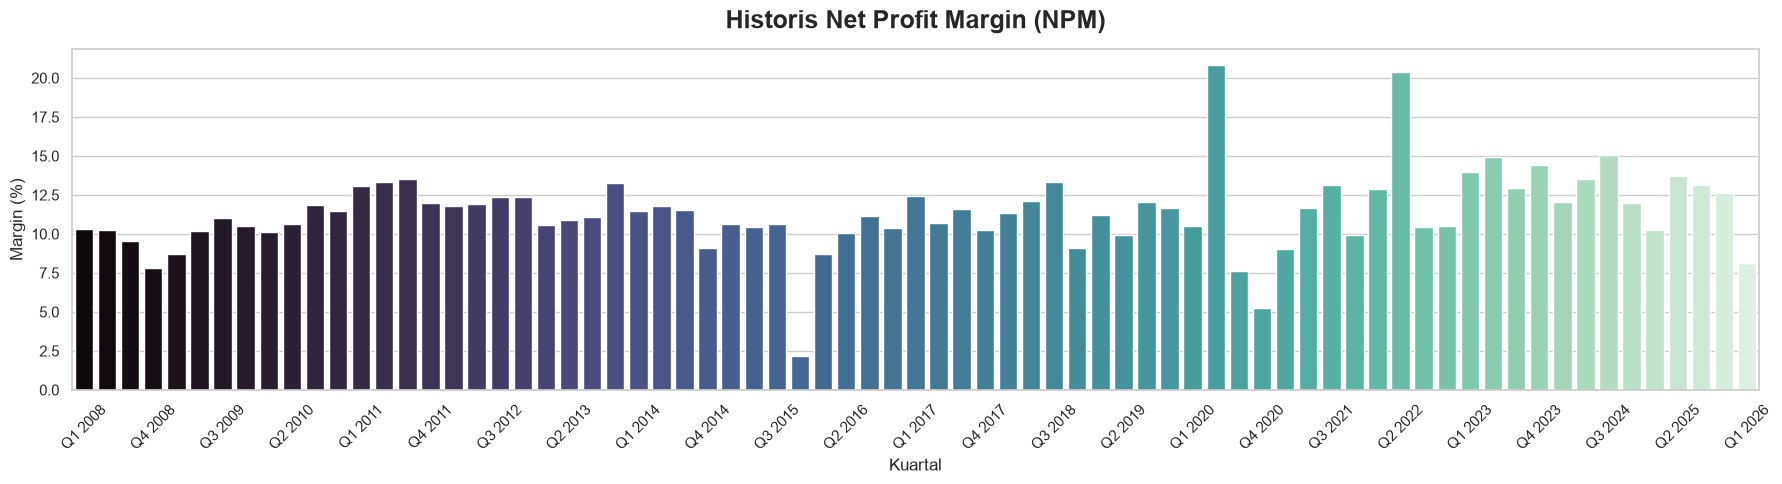

In [9]:
npm = (laba_bersih_urut / pendapatan_urut) * 100

fig, ax = plt.subplots(figsize=(18, 5))
sns.barplot(x=npm.index, y=npm.values, hue=npm.index, palette='mako', legend=False, ax=ax)

plt.title('Historis Net Profit Margin (NPM)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Kuartal', fontsize=12)
plt.ylabel('Margin (%)', fontsize=12)

# Membatasi label sumbu X agar rapi
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=25))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5. Pertumbuhan Pendapatan QoQ (Quarter-on-Quarter)
Untuk melihat volatilitas bisnis, kita akan menghitung persentase pertumbuhan pendapatan dari satu kuartal dibandingkan persis dengan kuartal sebelumnya. Metrik ini membantu kita mendeteksi apakah ada tren musiman tertentu atau dampak kondisi makroekonomi terhadap penjualan.

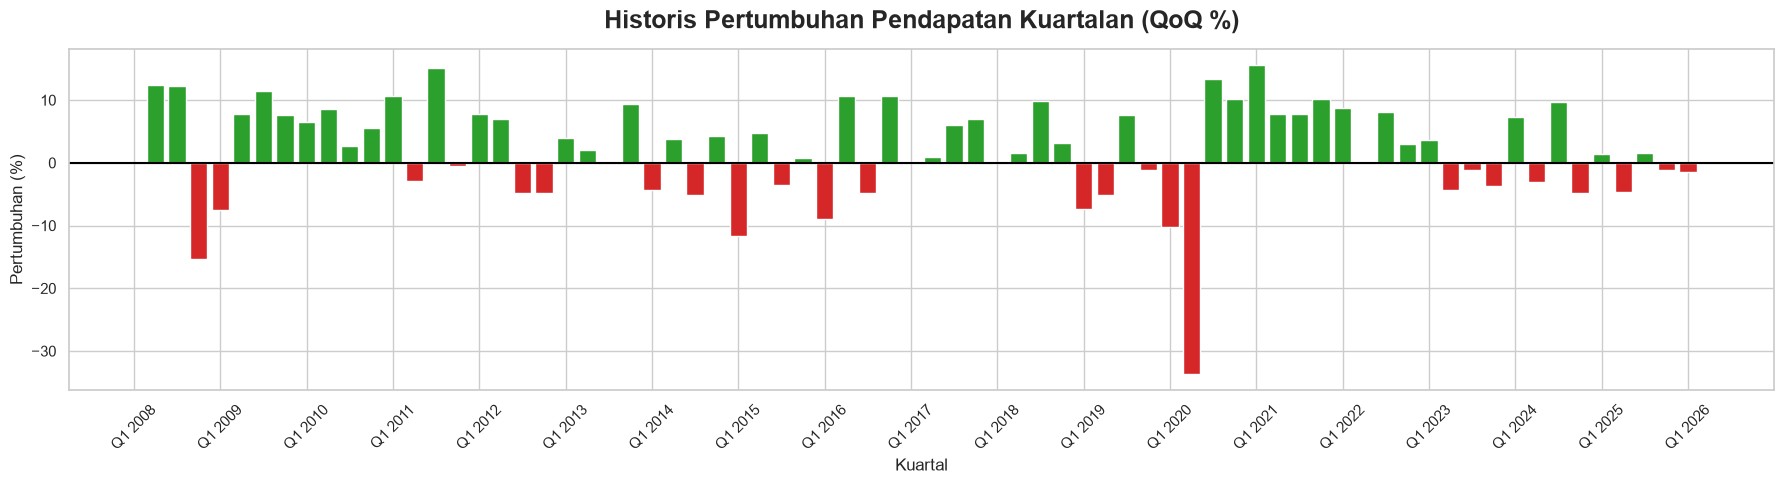

In [16]:
pertumbuhan_qoq = pendapatan_urut.pct_change() * 100

fig, ax = plt.subplots(figsize=(18, 5))

warna_pertumbuhan = ['#2ca02c' if val > 0 else '#d62728' for val in pertumbuhan_qoq]
ax.bar(pertumbuhan_qoq.index, pertumbuhan_qoq.values, color=warna_pertumbuhan)

plt.title('Historis Pertumbuhan Pendapatan Kuartalan (QoQ %)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Kuartal', fontsize=12)
plt.ylabel('Pertumbuhan (%)', fontsize=12)

# Membatasi label sumbu X agar rapi
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=25))
plt.xticks(rotation=45)

plt.axhline(0, color='black', linewidth=1.5) 

plt.tight_layout()
plt.show()

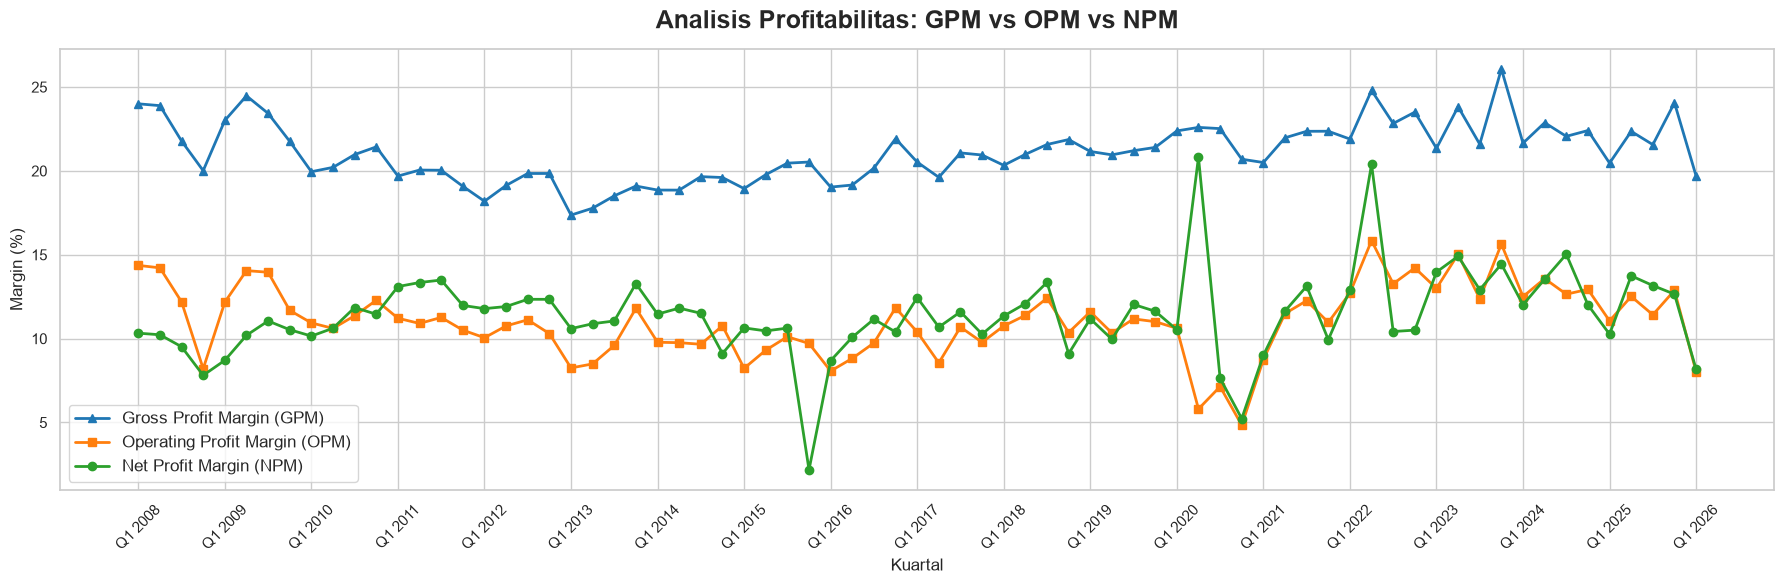

In [17]:
# Ekstraksi dan pembalikan urutan data tambahan
laba_kotor = df.loc['Laba Kotor'].dropna()[::-1]
laba_usaha = df.loc['Laba Usaha'].dropna()[::-1]

laba_kotor = pd.to_numeric(laba_kotor, errors='coerce')
laba_usaha = pd.to_numeric(laba_usaha, errors='coerce')

# Hitung GPM dan OPM
gpm = (laba_kotor / pendapatan_urut) * 100
opm = (laba_usaha / pendapatan_urut) * 100

fig, ax = plt.subplots(figsize=(18, 6))

# Plot ketiga margin
ax.plot(gpm.index, gpm.values, marker='^', color='#1f77b4', linewidth=2, label='Gross Profit Margin (GPM)')
ax.plot(opm.index, opm.values, marker='s', color='#ff7f0e', linewidth=2, label='Operating Profit Margin (OPM)')
ax.plot(npm.index, npm.values, marker='o', color='#2ca02c', linewidth=2, label='Net Profit Margin (NPM)')

plt.title('Analisis Profitabilitas: GPM vs OPM vs NPM', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Kuartal', fontsize=12)
plt.ylabel('Margin (%)', fontsize=12)

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=25))
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

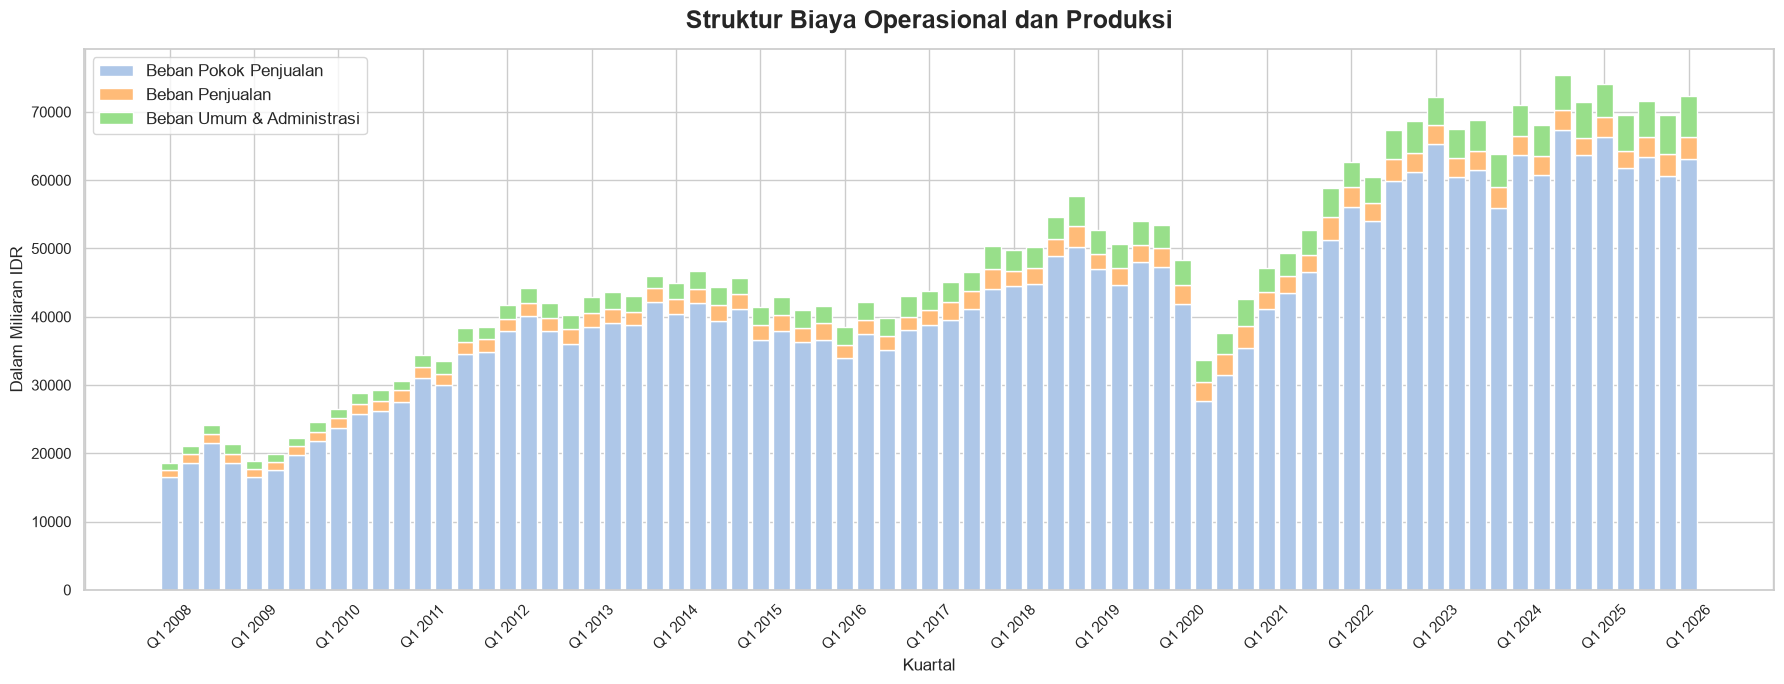

In [19]:
import matplotlib.ticker as ticker

# 1. Ekstraksi dan balik urutan
beban_pokok = df.loc['Total Beban Pokok Penjualan'].dropna()[::-1]
beban_penjualan = df.loc['Beban Penjualan'].dropna()[::-1]
beban_umum = df.loc['Beban Umum Dan Administrasi'].dropna()[::-1]

# 2. Ubah jadi numerik DULU, baru dikenakan abs() (nilai mutlak agar grafiknya positif ke atas)
beban_pokok = pd.to_numeric(beban_pokok, errors='coerce').abs()
beban_penjualan = pd.to_numeric(beban_penjualan, errors='coerce').abs()
beban_umum = pd.to_numeric(beban_umum, errors='coerce').abs()

fig, ax = plt.subplots(figsize=(18, 7))

# 3. Membuat stacked bar chart
p1 = ax.bar(beban_pokok.index, beban_pokok.values, color='#aec7e8', label='Beban Pokok Penjualan')
p2 = ax.bar(beban_penjualan.index, beban_penjualan.values, bottom=beban_pokok.values, color='#ffbb78', label='Beban Penjualan')
p3 = ax.bar(beban_umum.index, beban_umum.values, bottom=beban_pokok.values + beban_penjualan.values, color='#98df8a', label='Beban Umum & Administrasi')

plt.title('Struktur Biaya Operasional dan Produksi', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Kuartal', fontsize=12)
plt.ylabel('Dalam Miliaran IDR', fontsize=12)

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=25))
plt.xticks(rotation=45)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

## 6. Pertumbuhan Pendapatan YoY (Year-on-Year)
Berbeda dengan QoQ yang rentan terhadap efek musiman (misalnya lonjakan penjualan setiap Idul Fitri), pertumbuhan YoY membandingkan kinerja sebuah kuartal dengan kuartal yang sama di tahun sebelumnya (contoh: Q1 2024 vs Q1 2023). Ini memberikan gambaran pertumbuhan bisnis sejati yang jauh lebih akurat.

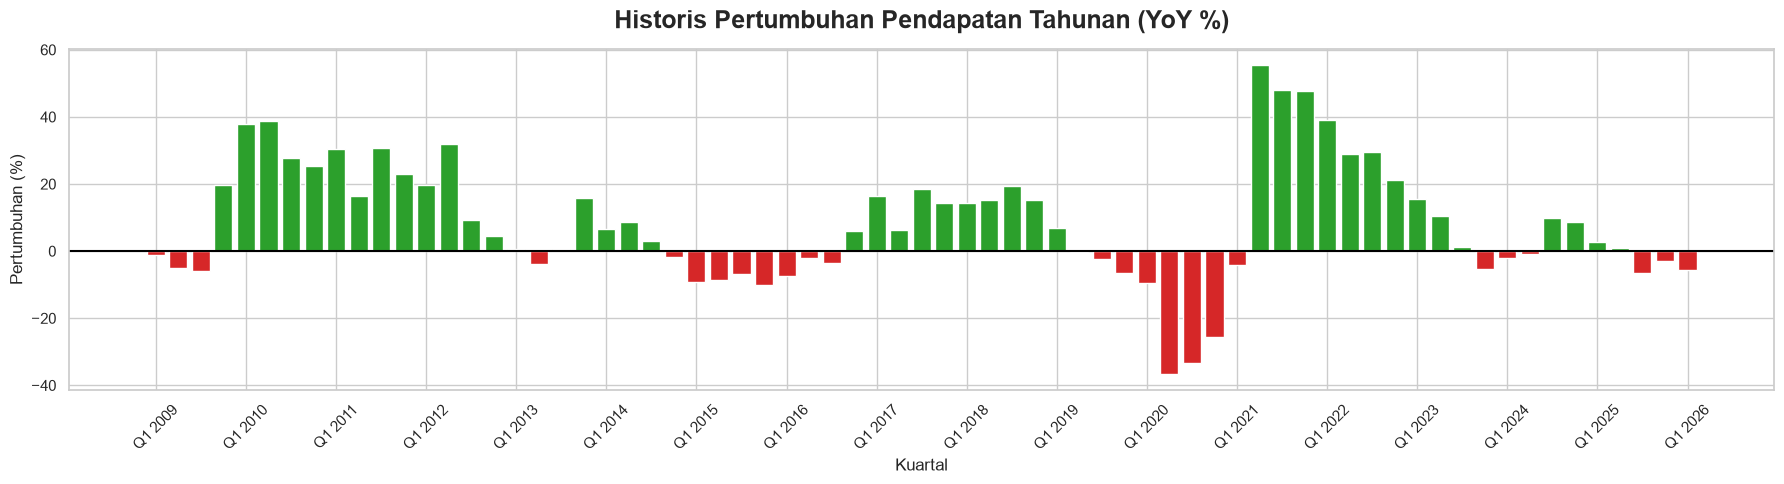

In [20]:
# Menghitung persentase perubahan YoY (jarak 4 kuartal ke belakang)
pertumbuhan_yoy = pendapatan_urut.pct_change(periods=4) * 100

fig, ax = plt.subplots(figsize=(18, 5))

# Pengkondisian warna: Hijau jika tumbuh (positif), Merah jika turun (negatif)
warna_yoy = ['#2ca02c' if val > 0 else '#d62728' for val in pertumbuhan_yoy]

# Menggunakan dropna() agar kuartal awal yang belum punya pembanding tahun sebelumnya tidak memunculkan bar kosong
ax.bar(pertumbuhan_yoy.dropna().index, pertumbuhan_yoy.dropna().values, color=warna_yoy[4:])

plt.title('Historis Pertumbuhan Pendapatan Tahunan (YoY %)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Kuartal', fontsize=12)
plt.ylabel('Pertumbuhan (%)', fontsize=12)

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=25))
plt.xticks(rotation=45)

# Garis batas 0
plt.axhline(0, color='black', linewidth=1.5) 

plt.tight_layout()
plt.show()

### Catatan Analisis: Mengapa Kita Membutuhkan QoQ dan YoY?

Dalam menganalisis performa emiten, membaca angka absolut saja sering kali tidak cukup untuk melihat arah pergerakan bisnis. Kita membutuhkan metrik pertumbuhan, di mana **QoQ** dan **YoY** memiliki fungsi analitik yang berbeda:

*   **QoQ (Quarter-on-Quarter):** Membandingkan performa kuartal saat ini dengan **kuartal tepat sebelumnya** (contoh: Q2 2024 vs Q1 2024). 
    *   *Fungsi:* Sangat baik untuk mendeteksi momentum jangka pendek, kelincahan operasional, atau respons langsung pasar terhadap strategi terbaru perusahaan.
    *   *Kelemahan:* Rentan terhadap bias **efek musiman (*seasonality*)**. Misalnya, penjualan otomotif atau ritel biasanya selalu melonjak di kuartal yang bertepatan dengan Idul Fitri. Lonjakan ini akan membuat QoQ terlihat sangat positif, namun berisiko anjlok di kuartal berikutnya (siklus normal).

*   **YoY (Year-on-Year):** Membandingkan performa kuartal saat ini dengan **kuartal yang sama persis di tahun sebelumnya** (contoh: Q2 2024 vs Q2 2023).
    *   *Fungsi:* Indikator terbaik untuk mengukur **pertumbuhan bisnis yang sejati**. Dengan membandingkan dua periode waktu yang identik secara siklus (misalnya, sama-sama kuartal yang memiliki momen libur panjang), kita berhasil meniadakan bias efek musiman. Jika metrik YoY menunjukkan tren positif yang konsisten, itu menandakan fundamental perusahaan benar-benar sedang berekspansi.